# Task 2: Topic Modeling using LDA and NMF

Topic modeling is an unsupervised machine learning technique used to discover hidden topics in a collection of documents.

In this notebook we will:
1. Load the 20 Newsgroups dataset
2. Clean the text
3. Convert text into numerical vectors
4. Apply LDA (Latent Dirichlet Allocation)
5. Apply NMF (Non-negative Matrix Factorization)
6. Extract hidden topics

In [7]:
# If needed (run once)
# !pip install nltk scikit-learn matplotlib

import re
import nltk
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

print("✅ Libraries Loaded")

✅ Libraries Loaded


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Step 1: Load Dataset

We use the **20 Newsgroups dataset** which contains thousands of documents from 20 different categories.

Each document belongs to a different topic such as sports, space, computers, politics etc.

In [8]:
dataset = fetch_20newsgroups(remove=('headers','footers','quotes'))

documents = dataset.data

print("Total documents:", len(documents))

Total documents: 11314


## Step 2: Text Preprocessing

Before topic modeling, text must be cleaned.

Steps performed:
• Convert text to lowercase  
• Remove numbers and special characters  
• Remove extra spaces


In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

clean_docs = [clean_text(doc) for doc in documents]

print("✅ Sample cleaned text:\n")
print(clean_docs[0][:500])

✅ Sample cleaned text:

i was wondering if anyone out there could enlighten me on this car i saw the other day it was a door sports car looked to be from the late s early s it was called a bricklin the doors were really small in addition the front bumper was separate from the rest of the body this is all i know if anyone can tellme a model name engine specs years of production where this car is made history or whatever info you have on this funky looking car please e mail 


# Step 3: Convert Text into Numerical Form

Machine learning models cannot understand text directly.

So we convert text into numbers using **Vectorization**.

For LDA we use **CountVectorizer**.

In [10]:
count_vectorizer = CountVectorizer(stop_words='english')

doc_term_matrix = count_vectorizer.fit_transform(clean_docs)

print("✅ Document-Term Matrix Shape:", doc_term_matrix.shape)

✅ Document-Term Matrix Shape: (11314, 72607)


## Step 4: Apply LDA Model

LDA identifies hidden topics by analyzing the distribution of words across documents.

Each topic is represented by a group of related words.

In [11]:
lda_model = LatentDirichletAllocation(
    n_components=10,
    random_state=42
)

lda_model.fit(doc_term_matrix)

print("✅ LDA Model Trained")

✅ LDA Model Trained


## Step 5: Extract Topics from LDA

In [12]:
words = count_vectorizer.get_feature_names_out()

print("\n📌 LDA Topics:\n")

for topic_idx, topic in enumerate(lda_model.components_):
    print(f"\nTopic {topic_idx}:")
    print([words[i] for i in topic.argsort()[-10:]])


📌 LDA Topics:


Topic 0:
['like', 'game', 'know', 'good', 'just', 'mr', 'gun', 'think', 'don', 'year']

Topic 1:
['jewish', 'players', 'mov', 'like', 'just', 'arab', 'jews', 'israeli', 'israel', 'db']

Topic 2:
['clipper', 'turkish', 'law', 'encryption', 'key', 'armenian', 'new', 'use', 'people', 'government']

Topic 3:
['mw', 'mv', 'mc', 'lk', 'ck', 'uw', 'ww', 'qs', 'hz', 'cx']

Topic 4:
['disk', 'used', 'know', 'mb', 'scsi', 'key', 'like', 'use', 'bit', 'drive']

Topic 5:
['ey', 'wm', 'bhj', 'giz', 'ei', 'tm', 'di', 'pl', 'max', 'ax']

Topic 6:
['data', 'use', 'pub', 'mail', 'file', 'ftp', 'information', 'available', 'com', 'edu']

Topic 7:
['output', 'does', 'using', 'problem', 'window', 'dos', 'program', 'use', 'file', 'windows']

Topic 8:
['does', 'say', 'time', 'think', 'like', 'know', 'just', 'don', 'god', 'people']

Topic 9:
['st', 'nhl', 'games', 'pts', 'la', 'edu', 'bike', 'new', 'vs', 'hockey']


In [13]:
#lda score 
lda_perplexity = lda_model.perplexity(doc_term_matrix)

print("\n✅ LDA Perplexity Score:", lda_perplexity)


✅ LDA Perplexity Score: 4775.047667261146


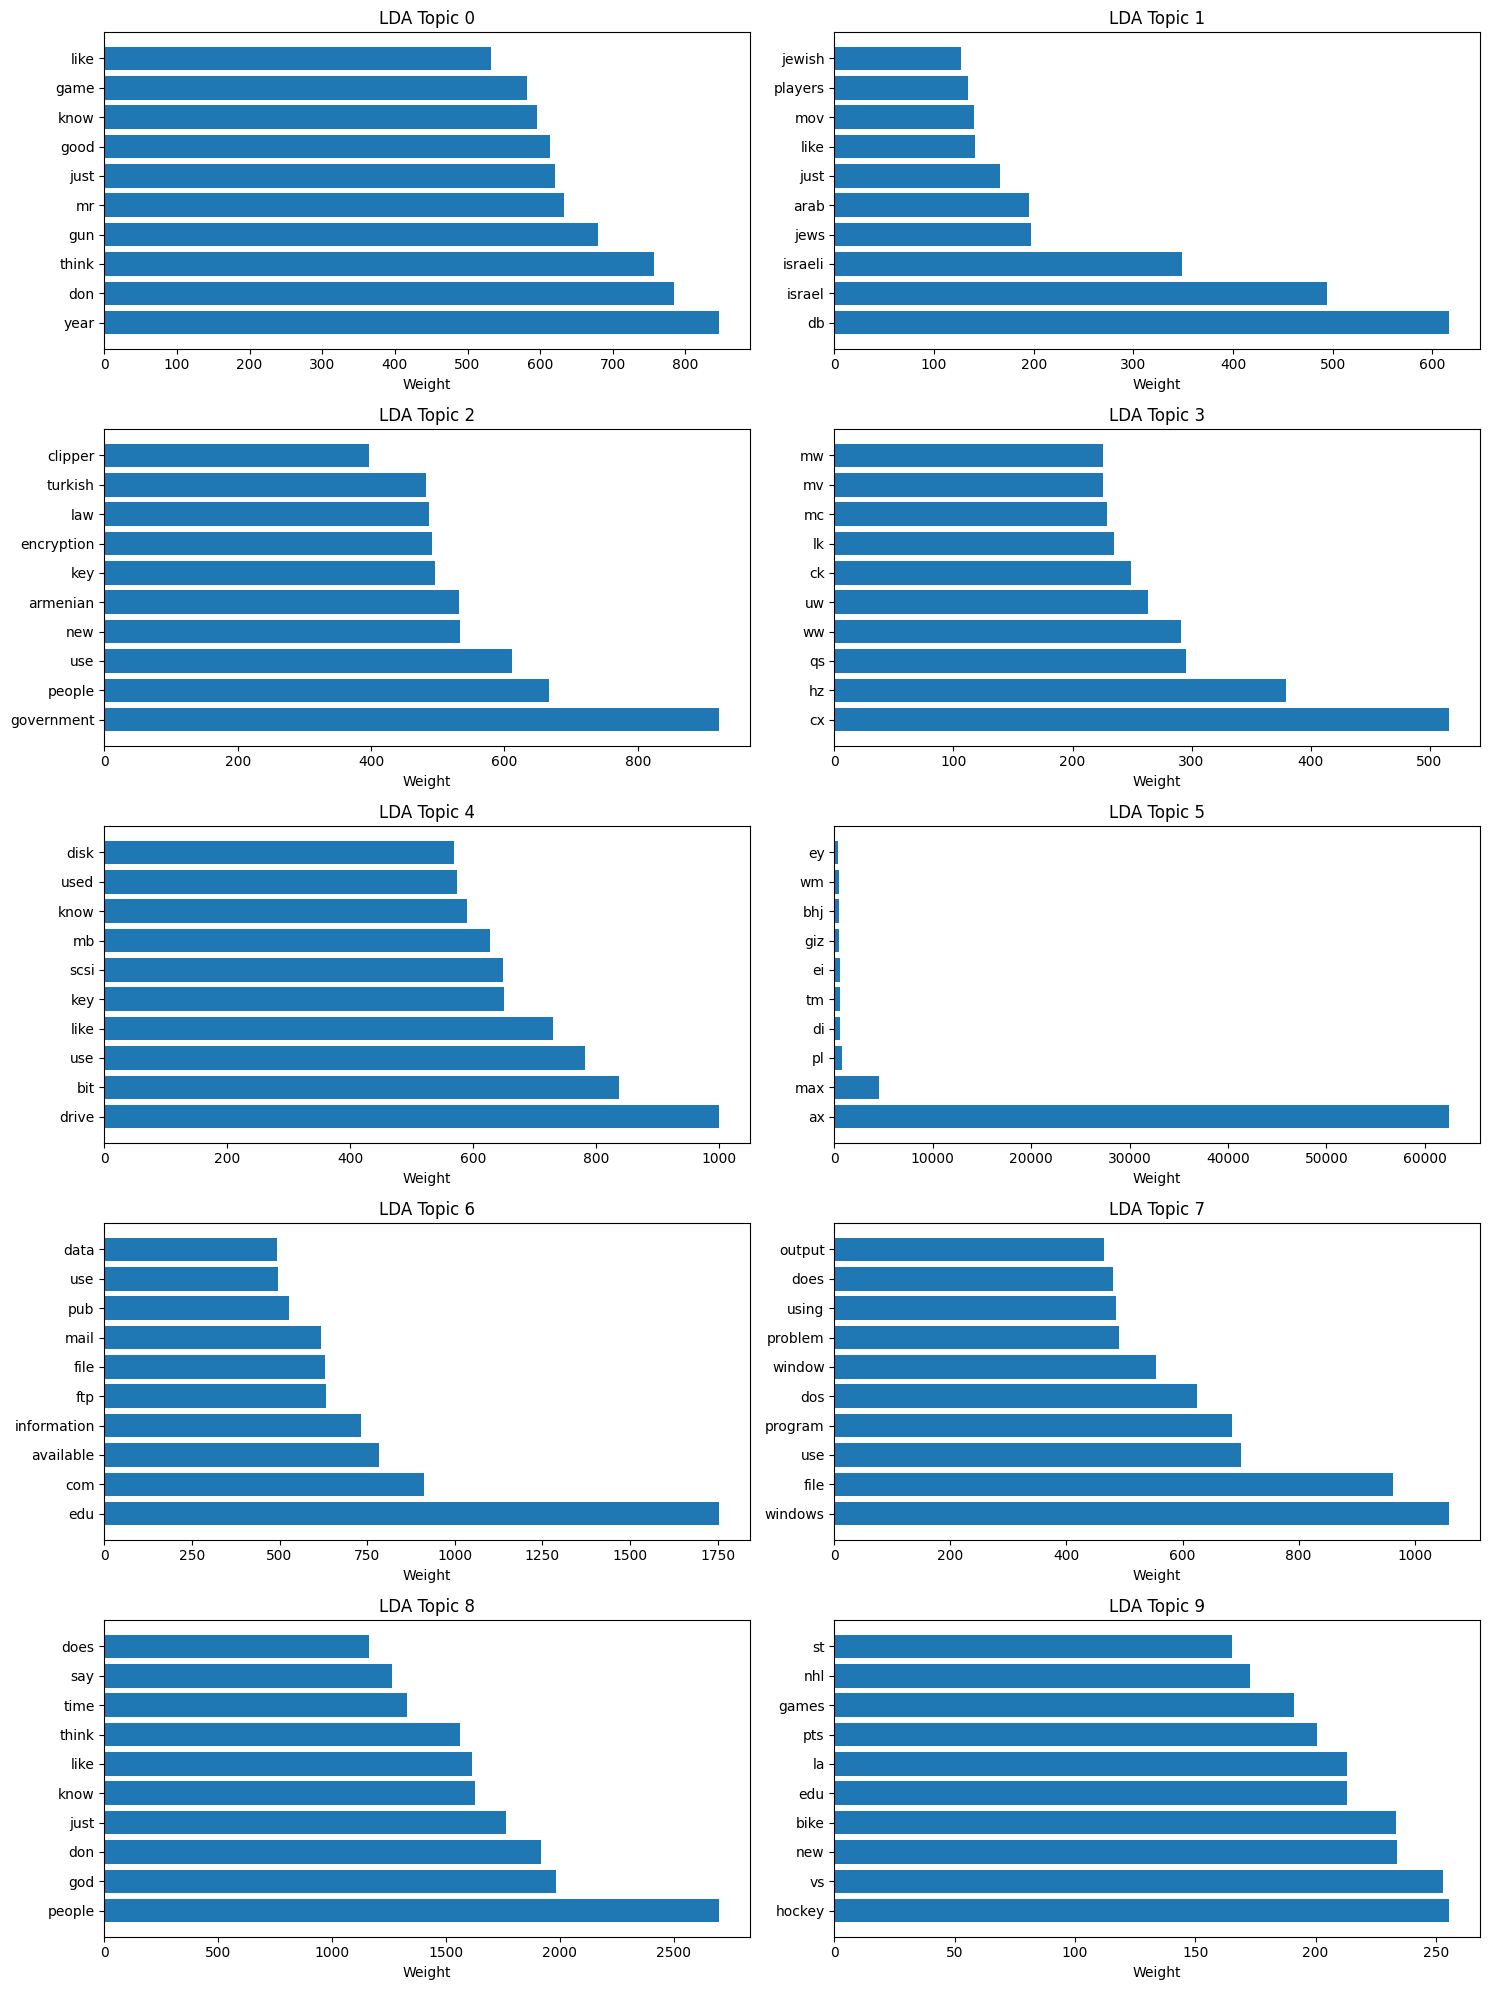

In [24]:
import matplotlib.pyplot as plt

# Get feature names for LDA
lda_words = count_vectorizer.get_feature_names_out()

num_topics = lda_model.components_.shape[0]

fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for topic_idx, topic in enumerate(lda_model.components_):
    
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [lda_words[i] for i in top_words_idx]
    top_weights = topic[top_words_idx]
    
    axes[topic_idx].barh(top_words, top_weights)
    axes[topic_idx].set_title(f'LDA Topic {topic_idx}')
    axes[topic_idx].set_xlabel('Weight')

plt.tight_layout()
plt.show()

## Step 6: Topic Modeling using NMF

NMF is another topic modeling algorithm.

It uses matrix factorization to discover hidden patterns in text data.

In [14]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(clean_docs)

nmf_model = NMF(n_components=10, random_state=42)
nmf_model.fit(tfidf_matrix)

,"n_components n_components: int or {'auto'} or None, default='auto'Number of components. If `None`, all features are kept.If `n_components='auto'`, the number of components is automatically inferredfrom W or H shapes... versionchanged:: 1.4 Added `'auto'` value... versionchanged:: 1.6 Default value changed from `None` to `'auto'`.",10
,"init init: {'random', 'nndsvd', 'nndsvda', 'nndsvdar', 'custom'}, default=NoneMethod used to initialize the procedure.Valid options:- `None`: 'nndsvda' if n_components <= min(n_samples, n_features), otherwise random.- `'random'`: non-negative random matrices, scaled with: `sqrt(X.mean() / n_components)`- `'nndsvd'`: Nonnegative Double Singular Value Decomposition (NNDSVD) initialization (better for sparseness)- `'nndsvda'`: NNDSVD with zeros filled with the average of X (better when sparsity is not desired)- `'nndsvdar'` NNDSVD with zeros filled with small random values (generally faster, less accurate alternative to NNDSVDa for when sparsity is not desired)- `'custom'`: Use custom matrices `W` and `H` which must both be provided... versionchanged:: 1.1 When `init=None` and n_components is less than n_samples and n_features defaults to `nndsvda` instead of `nndsvd`.",None
,"solver solver: {'cd', 'mu'}, default='cd'Numerical solver to use:- 'cd' is a Coordinate Descent solver.- 'mu' is a Multiplicative Update solver... versionadded:: 0.17 Coordinate Descent solver... versionadded:: 0.19 Multiplicative Update solver.",'cd'
,"beta_loss beta_loss: float or {'frobenius', 'kullback-leibler', 'itakura-saito'}, default='frobenius'Beta divergence to be minimized, measuring the distance between Xand the dot product WH. Note that values different from 'frobenius'(or 2) and 'kullback-leibler' (or 1) lead to significantly slowerfits. Note that for beta_loss <= 0 (or 'itakura-saito'), the inputmatrix X cannot contain zeros. Used only in 'mu' solver... versionadded:: 0.19",'frobenius'
,"tol tol: float, default=1e-4Tolerance of the stopping condition.",0.0001
,"max_iter max_iter: int, default=200Maximum number of iterations before timing out.",200
,"random_state random_state: int, RandomState instance or None, default=NoneUsed for initialisation (when ``init`` == 'nndsvdar' or'random'), and in Coordinate Descent. Pass an int for reproducibleresults across multiple function calls.See :term:`Glossary `.",42
,"alpha_W alpha_W: float, default=0.0Constant that multiplies the regularization terms of `W`. Set it to zero(default) to have no regularization on `W`... versionadded:: 1.0",0.0
,"alpha_H alpha_H: float or ""same"", default=""same""Constant that multiplies the regularization terms of `H`. Set it to zero tohave no regularization on `H`. If ""same"" (default), it takes the same value as`alpha_W`... versionadded:: 1.0",'same'
,"l1_ratio l1_ratio: float, default=0.0The regularization mixing parameter, with 0 <= l1_ratio <= 1.For l1_ratio = 0 the penalty is an elementwise L2 penalty(aka Frobenius Norm).For l1_ratio = 1 it is an elementwise L1 penalty.For 0 < l1_ratio < 1, the penalty is a combination of L1 and L2... versionadded:: 0.17 Regularization parameter *l1_ratio* used in the Coordinate Descent solver.",0.0
,"verbose verbose: int, default=0Whether to be verbose.",0


In [15]:
nmf_model = NMF(
    n_components=10,
    random_state=42
)

nmf_model.fit(tfidf_matrix)

print("✅ NMF Model Trained")

✅ NMF Model Trained


In [16]:
words = tfidf.get_feature_names_out()

print("\n📌 NMF Topics:\n")

for topic_idx, topic in enumerate(nmf_model.components_):
    print(f"\nTopic {topic_idx}:")
    print([words[i] for i in topic.argsort()[-10:]])


📌 NMF Topics:


Topic 0:
['bit', 'use', 'algorithm', 'government', 'escrow', 'keys', 'clipper', 'encryption', 'chip', 'key']

Topic 1:
['version', 'running', 'using', 'use', 'program', 'files', 'window', 'file', 'dos', 'windows']

Topic 2:
['say', 'does', 'christians', 'christian', 'christ', 'faith', 'believe', 'bible', 'jesus', 'god']

Topic 3:
['really', 'time', 'car', 've', 'good', 'know', 'think', 'like', 'don', 'just']

Topic 4:
['surrender', 'skepticism', 'intellect', 'shameful', 'pitt', 'chastity', 'jxp', 'cadre', 'dsl', 'geb']

Topic 5:
['cd', 'floppy', 'controller', 'ide', 'hard', 'drives', 'disk', 'mb', 'scsi', 'drive']

Topic 6:
['address', 'email', 'looking', 'hi', 'info', 'advance', 'know', 'does', 'mail', 'thanks']

Topic 7:
['league', 'win', 'play', 'hockey', 'season', 'players', 'year', 'games', 'team', 'game']

Topic 8:
['bit', 'ram', 'drivers', 'cards', 'vga', 'bus', 'mb', 'monitor', 'video', 'card']

Topic 9:
['turkish', 'gun', 'armenians', 'state', 'israeli', 'jews

In [17]:
#nfm score 
nmf_error = nmf_model.reconstruction_err_

print("\n✅ NMF Reconstruction Error:", nmf_error)


✅ NMF Reconstruction Error: 103.26436797966258


In [18]:
lda_perplexity = lda_model.perplexity(doc_term_matrix)

print("LDA Perplexity:", lda_perplexity)

LDA Perplexity: 4775.047667261146


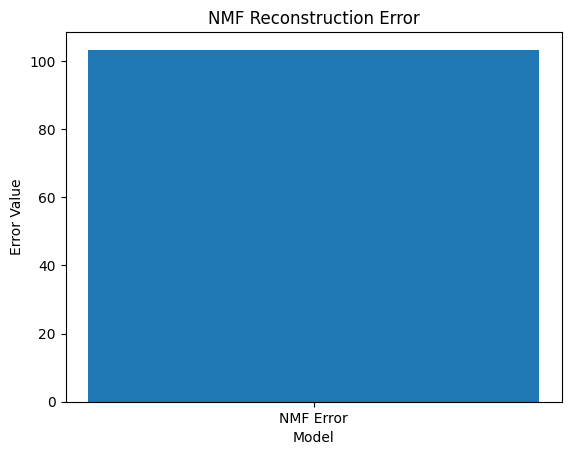

In [19]:

import matplotlib.pyplot as plt

plt.figure()
plt.bar(['NMF Error'], [nmf_error])
plt.title("NMF Reconstruction Error")
plt.xlabel("Model")
plt.ylabel("Error Value")
plt.show()

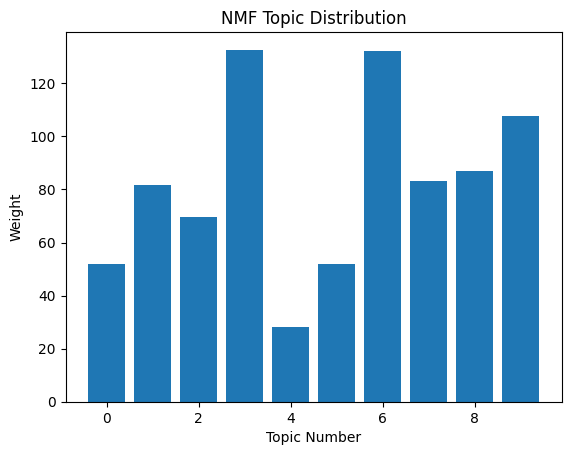

In [20]:
import matplotlib.pyplot as plt
import numpy as np

nmf_output = nmf_model.transform(tfidf_matrix)

topic_strength = np.sum(nmf_output, axis=0)

plt.bar(range(10), topic_strength)

plt.title("NMF Topic Distribution")
plt.xlabel("Topic Number")
plt.ylabel("Weight")

plt.show()

In [37]:
import matplotlib.pyplot as plt

# Safety check
print("NMF Error:", nmf_error)

NMF Error: 103.26436797966258


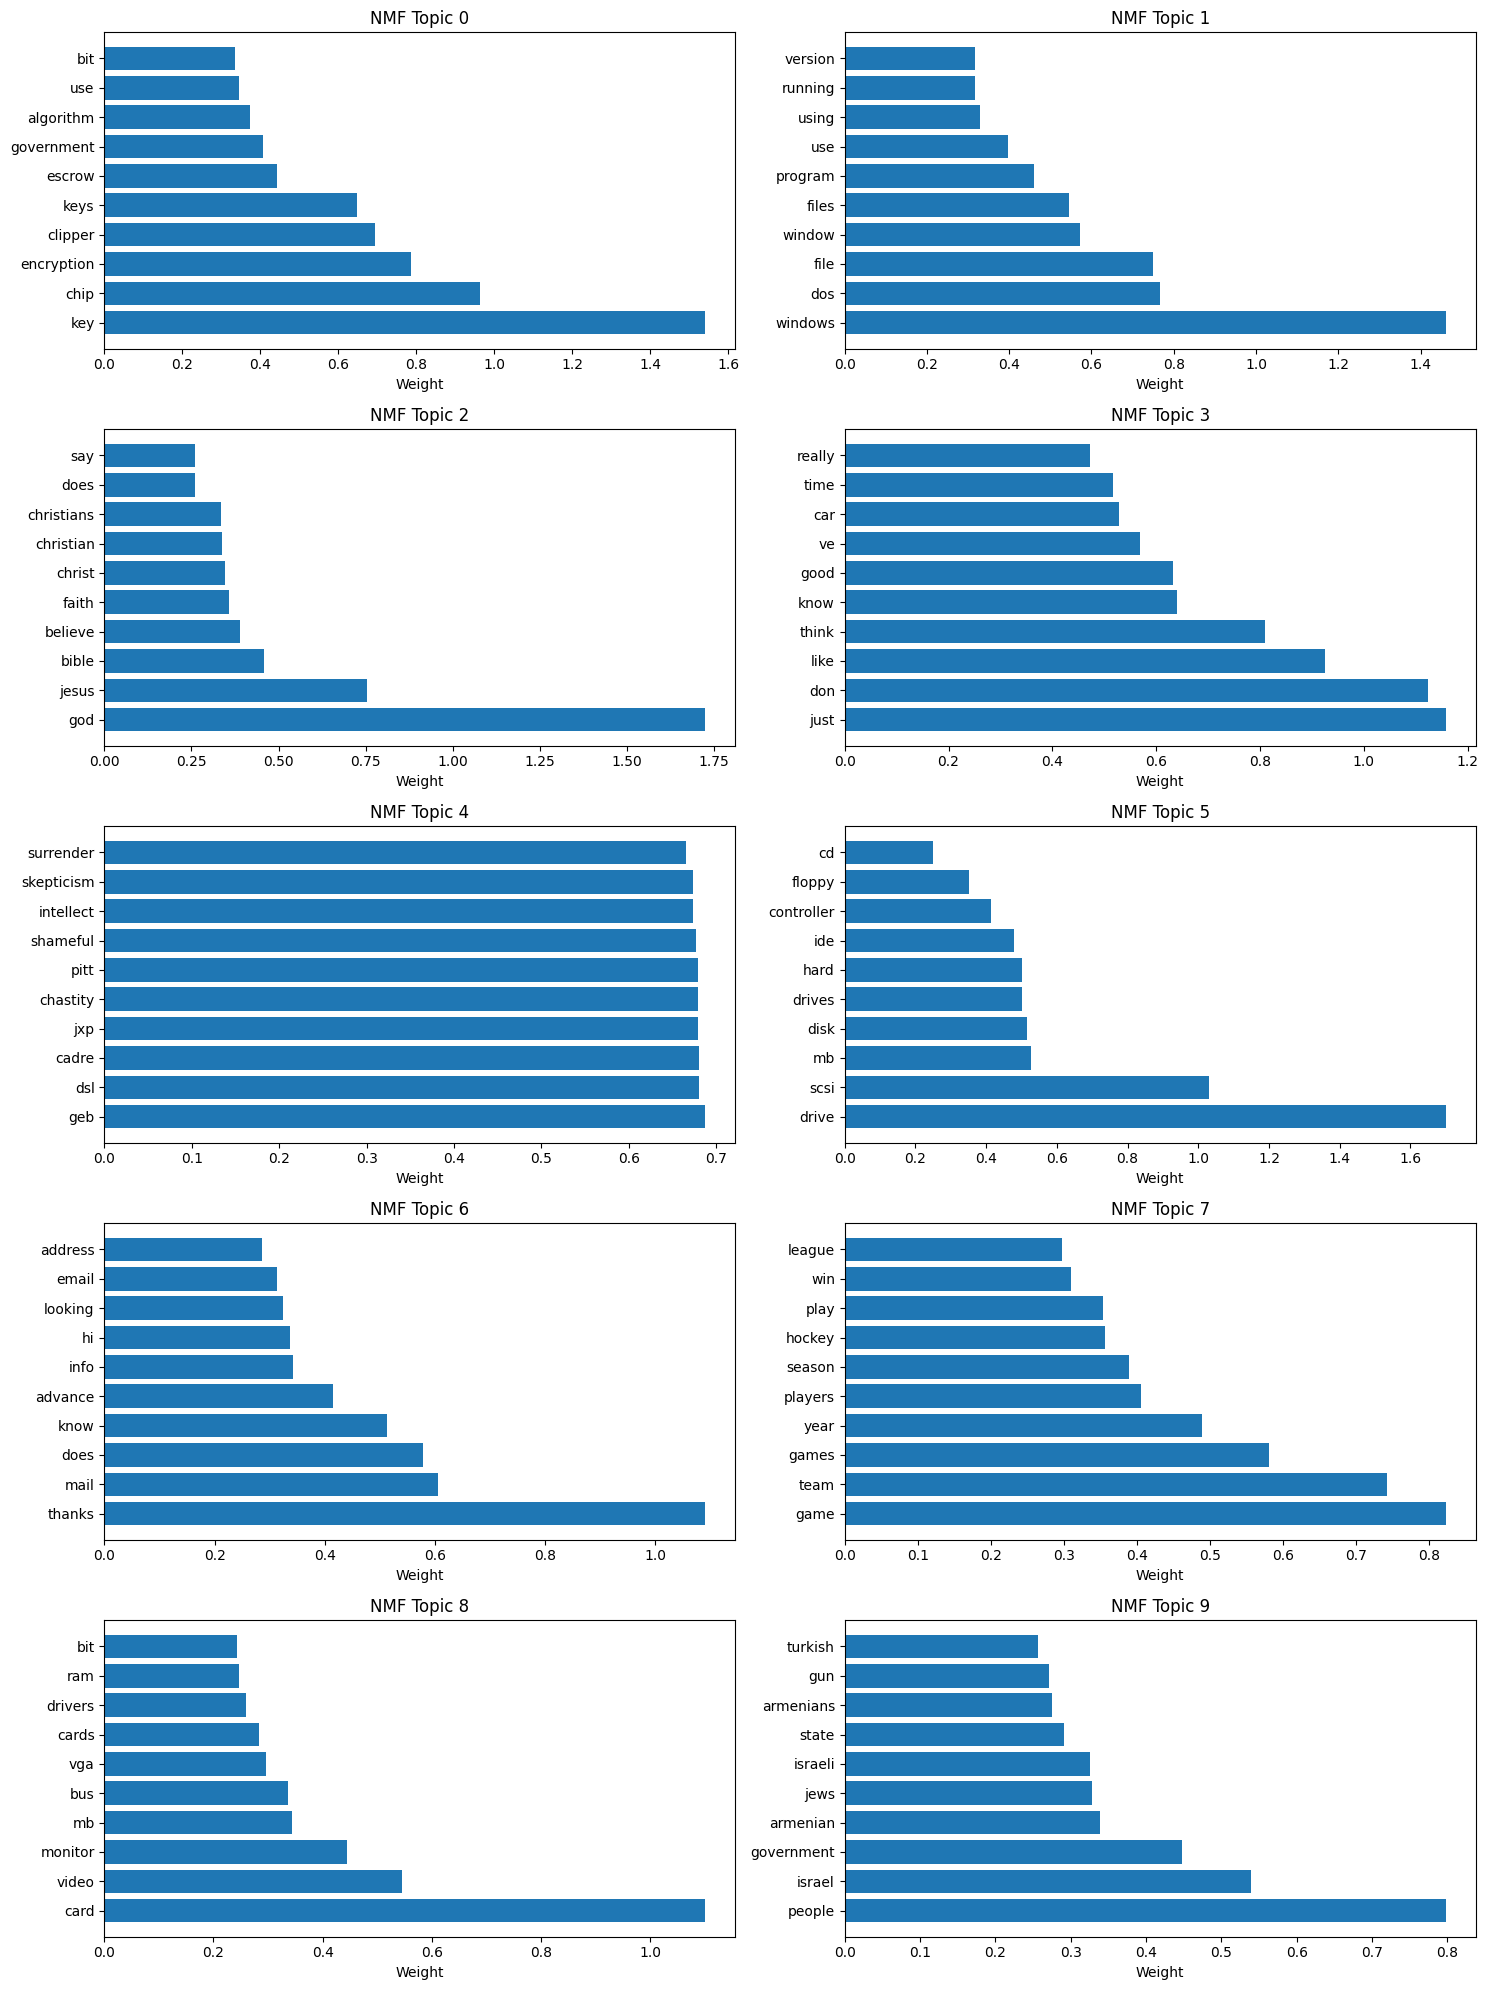

In [21]:
import matplotlib.pyplot as plt

# Get feature names
words = tfidf.get_feature_names_out()

num_topics = nmf_model.components_.shape[0]

fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for topic_idx, topic in enumerate(nmf_model.components_):
    
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [words[i] for i in top_words_idx]
    top_weights = topic[top_words_idx]
    
    axes[topic_idx].barh(top_words, top_weights)
    axes[topic_idx].set_title(f'NMF Topic {topic_idx}')
    axes[topic_idx].set_xlabel('Weight')

plt.tight_layout()
plt.show()

## Comparison: LDA vs NMF

Now let's compare the performance and characteristics of both models.

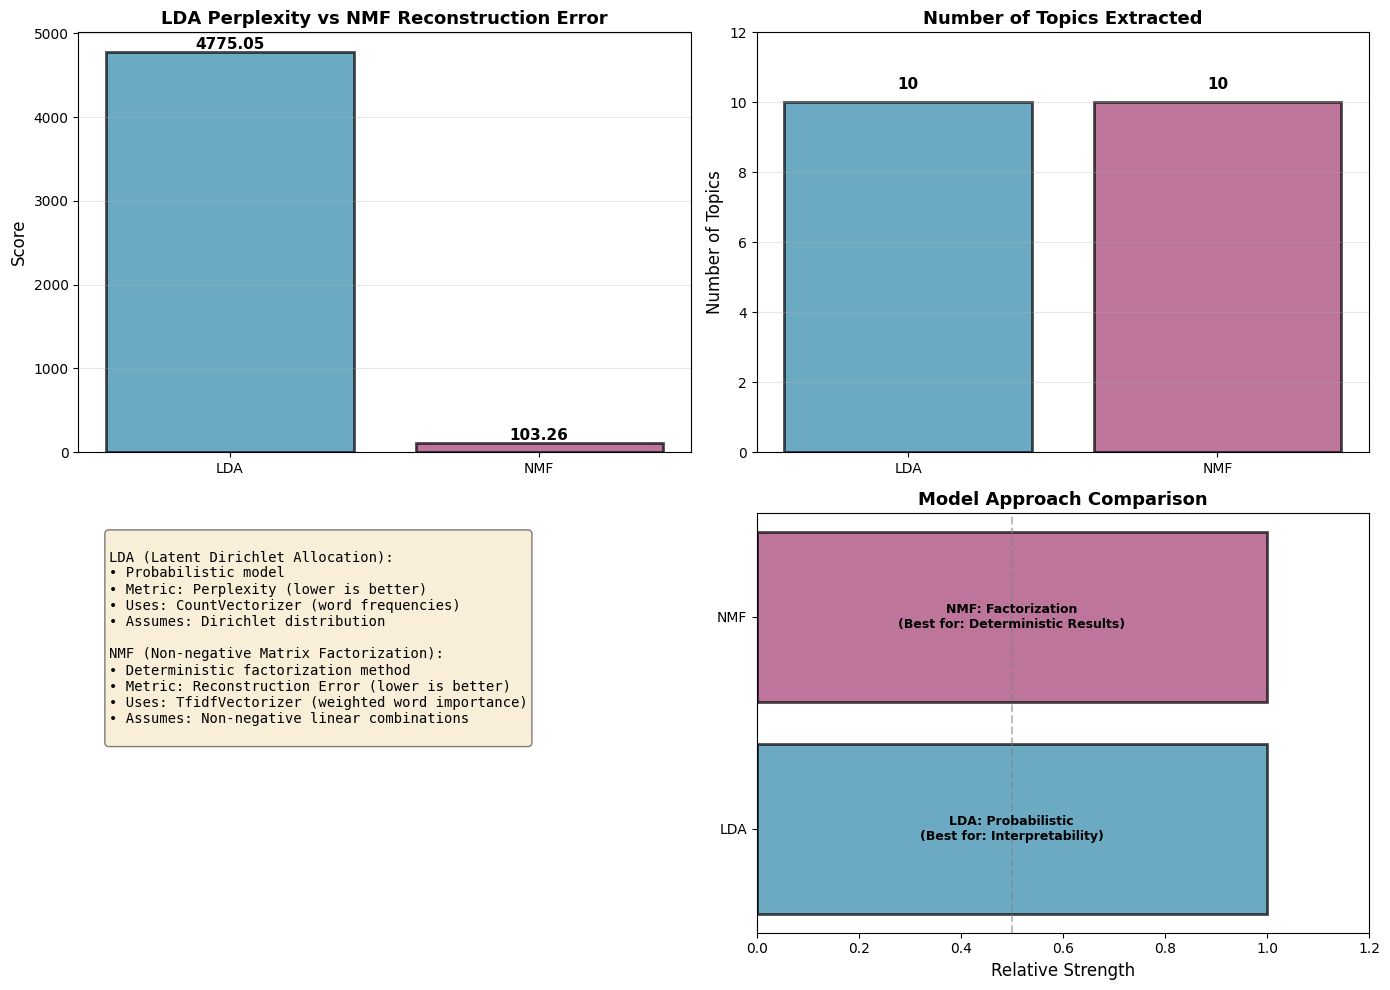


LDA vs NMF SUMMARY

LDA Perplexity Score: 4775.0477
NMF Reconstruction Error: 103.2644

Both models extracted 10 topics from the dataset

Interpretation:
• Lower LDA perplexity = Better generalization to unseen data
• Lower NMF error = Better factorization fit to training data


In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Model Performance Metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Perplexity vs Reconstruction Error
ax = axes[0, 0]
models = ['LDA', 'NMF']
metrics = [lda_perplexity, nmf_error]
colors = ['#2E86AB', '#A23B72']
bars = ax.bar(models, metrics, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('LDA Perplexity vs NMF Reconstruction Error', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, metric in zip(bars, metrics):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{metric:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Number of Topics Learned
ax = axes[0, 1]
num_lda_topics = lda_model.components_.shape[0]
num_nmf_topics = nmf_model.components_.shape[0]
ax.bar(['LDA', 'NMF'], [num_lda_topics, num_nmf_topics], color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Number of Topics', fontsize=12)
ax.set_title('Number of Topics Extracted', fontsize=13, fontweight='bold')
ax.set_ylim([0, 12])
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate([num_lda_topics, num_nmf_topics]):
    ax.text(i, v + 0.3, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

# 3. Algorithm Characteristics
ax = axes[1, 0]
ax.axis('off')
comparison_text = """
LDA (Latent Dirichlet Allocation):
• Probabilistic model
• Metric: Perplexity (lower is better)
• Uses: CountVectorizer (word frequencies)
• Assumes: Dirichlet distribution

NMF (Non-negative Matrix Factorization):
• Deterministic factorization method
• Metric: Reconstruction Error (lower is better)
• Uses: TfidfVectorizer (weighted word importance)
• Assumes: Non-negative linear combinations
"""
ax.text(0.05, 0.95, comparison_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Model Efficiency
ax = axes[1, 1]
model_info = [
    'LDA: Probabilistic\n(Best for: Interpretability)',
    'NMF: Factorization\n(Best for: Deterministic Results)'
]
y_pos = [0, 1]
ax.barh(y_pos, [1, 1], color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_yticks(y_pos)
ax.set_yticklabels(['LDA', 'NMF'])
ax.set_xlabel('Relative Strength', fontsize=12)
ax.set_title('Model Approach Comparison', fontsize=13, fontweight='bold')
ax.set_xlim([0, 1.2])
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
for i, info in enumerate(model_info):
    ax.text(0.5, i, info, ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("LDA vs NMF SUMMARY")
print("="*60)
print(f"\nLDA Perplexity Score: {lda_perplexity:.4f}")
print(f"NMF Reconstruction Error: {nmf_error:.4f}")
print(f"\nBoth models extracted {num_lda_topics} topics from the dataset")
print("\nInterpretation:")
print("• Lower LDA perplexity = Better generalization to unseen data")
print("• Lower NMF error = Better factorization fit to training data")
print("="*60)

## Conclusion

In this project, I used LDA and NMF for topic modeling. 
LDA uses perplexity and NMF uses reconstruction error. 
Graphs are used to understand model performance and topics.